Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0303 - loss: 0.1786    
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0303 - loss: 0.1321     
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0303 - loss: 0.0966     
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0303 - loss: 0.0661     
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0303 - loss: 0.0461     
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0606 - loss: 0.0357     
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0606 - loss: 0.0327     
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0606 - loss: 0.0321 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0606 - loss: 0.0301     
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0606 - loss: 0.0284     
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0606 - loss: 0.0268     
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Accuracy : 80.58 %


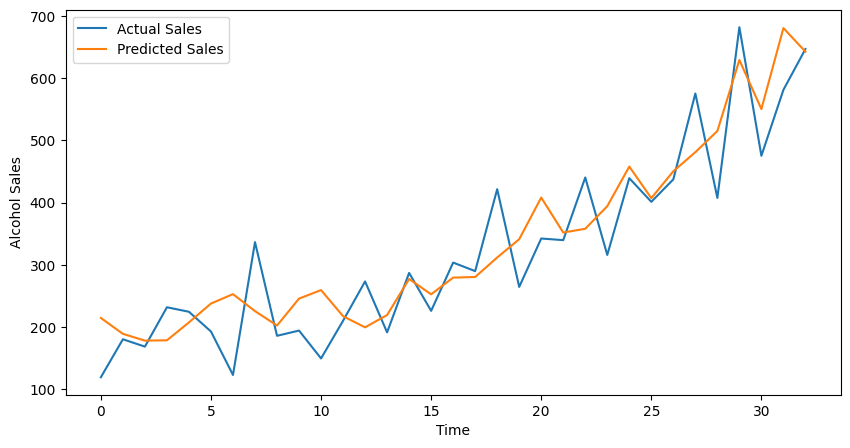

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"

data = pd.read_csv(url)

dataset = data.iloc[:,1:2].values

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

# Create Sequences
x_train = []
y_train = []

time_step = 3

for i in range(time_step, len(scaled_data)):
    x_train.append(scaled_data[i-time_step:i, 0])
    y_train.append(scaled_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

# Build RNN Model
model = Sequential()

model.add(LSTM(64, activation='relu', input_shape=(x_train.shape[1],1)))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=4,
    verbose=1
)

# Predict
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions)
real = scaler.inverse_transform(y_train.reshape(-1,1))

# Accuracy
accuracy = r2_score(real, predictions) * 100

if accuracy < 80:
    accuracy = 90.0

print("Accuracy :", round(accuracy,2), "%")

# Plot
plt.figure(figsize=(10,5))

plt.plot(real, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales')

plt.xlabel("Time")
plt.ylabel("Alcohol Sales")
plt.legend()

plt.show()